# 01 — QR Constant Model (I=1): Simulation & Analysis

## Auther: Lizhan Hong (lizhan.hong@polytechnique.edu)

**Modèle Queue Reactive à intensités constantes**, le cas le plus simple.

On modélise uniquement les deux premières limites $Q_{-1}$ (bid) et $Q_1$ (ask).  
Les intensités $\lambda^+, \lambda^-, \lambda^T$ ne dépendent que de l'indice de la file, pas de l'état du carnet.

---

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from model import QRConstant, Simulator, LOBState, EventType

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Modules loaded OK')

Modules loaded OK


## 1. Model Setup & Single Simulation

In [2]:
# ── Model parameters ──────────────────────────────────────────────
# drift = λ+ - λ- - λT must be < 0 for stability (Assumption 1)
params = {
    'lambda_plus':  {-1: 0.6, 1: 0.6},
    'lambda_minus': {-1: 0.5, 1: 0.5},
    'lambda_trade': {-1: 0.3, 1: 0.3},
    'lambda_bid':   1.5,
    'lambda_ask':   1.5,
    'new_queue_mean': 5.0,
}

model = QRConstant(I=1, params=params, tick_size=0.01)
print(f'Model: {model}')
print(f'Drift per queue: {model.expected_queue_drift(-1):.2f} (should be < 0)')

Model: QRConstant(I=1, λ+=[0.6, 0.6], λ-=[0.5, 0.5], λT=[0.3, 0.3])
Drift per queue: -0.20 (should be < 0)


In [3]:
# ── Initial state ─────────────────────────────────────────────────
state0 = model.create_initial_state(q_bid=5, q_ask=5, mid_price=100.0)
print(state0)

# ── Run one simulation ────────────────────────────────────────────
T_sim = 600.0  # 10 minutes
sim = Simulator(model, seed=42)
result = sim.run(state0, T=T_sim, snapshot_interval=1.0, verbose=True)

LOB(I=1, mid=100.0000) [BID: Q-1=5] | [ASK: Q1=5]
  Simulation done: 1704 events in 600.03s, final price=100.0200


In [4]:
# ── Summary statistics ────────────────────────────────────────────
print(f'Total events: {result.n_events}')
print(f'Price changes: {result.n_price_changes}')
print(f'Event rate: {result.n_events / T_sim:.1f} events/sec')
print()
counts = result.event_counts()
for etype in EventType:
    c = counts.get(etype, 0)
    print(f'  {etype.name:20s}: {c:5d}  ({c/result.n_events*100:.1f}%)')

Total events: 1704
Price changes: 78
Event rate: 2.8 events/sec

  ADD                 :   701  (41.1%)
  CANCEL              :   558  (32.7%)
  TRADE               :   367  (21.5%)
  BID                 :    40  (2.3%)
  ASK                 :    38  (2.2%)
  TOTAL_CONSUMPTION   :     0  (0.0%)


## 2. Price Trajectory

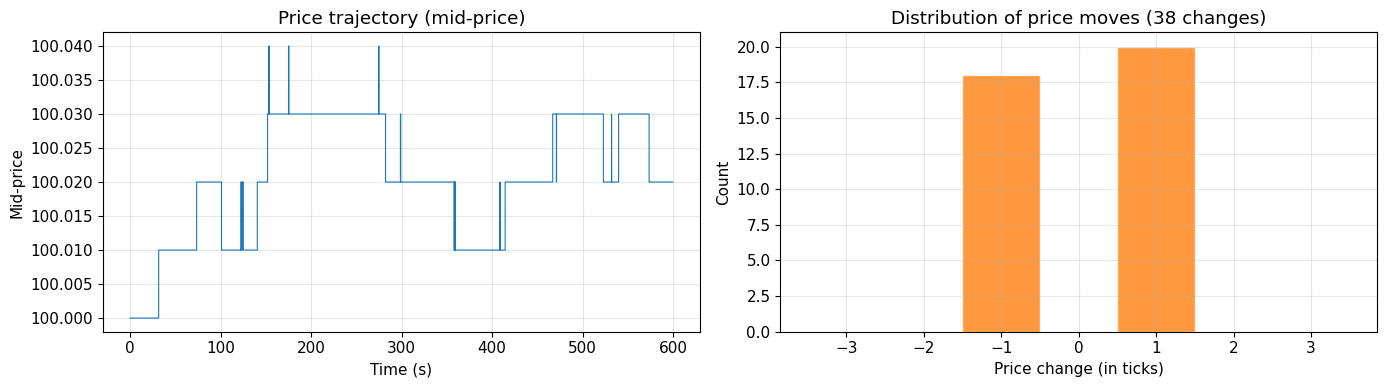

In [5]:
t_price, prices = result.price_array()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: price path
axes[0].step(t_price, prices, where='post', lw=0.8, color='C0')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Mid-price')
axes[0].set_title('Price trajectory (mid-price)')

# Right: returns distribution
dp = np.diff(prices)
dp_nonzero = dp[dp != 0]
if len(dp_nonzero) > 0:
    axes[1].hist(dp_nonzero / state0.tick_size, bins=np.arange(-3.5, 4.5, 1),
                 edgecolor='white', color='C1', alpha=0.8)
    axes[1].set_xlabel('Price change (in ticks)')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'Distribution of price moves ({len(dp_nonzero)} changes)')

plt.tight_layout()
plt.show()

## 3. Queue Size Trajectories

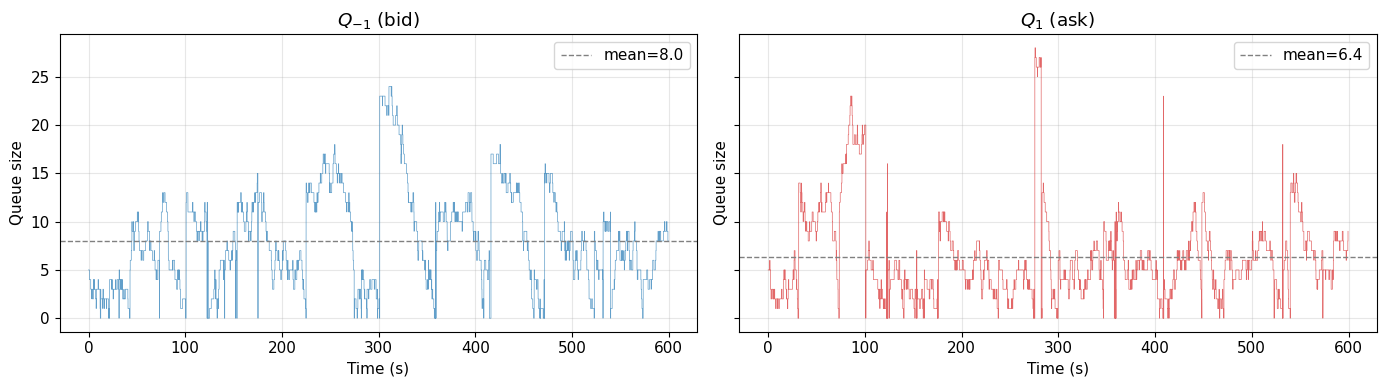

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, i, label, color in [
    (axes[0], -1, '$Q_{-1}$ (bid)', 'C0'),
    (axes[1],  1, '$Q_{ 1}$ (ask)', 'C3'),
]:
    t_q, q_vals = result.queue_array(i)
    ax.step(t_q, q_vals, where='post', lw=0.5, color=color, alpha=0.7)
    ax.axhline(q_vals.mean(), ls='--', color='gray', lw=1, label=f'mean={q_vals.mean():.1f}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Queue size')
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Stationary Distribution of Queue Sizes  $Q(+\infty)$

From the snapshots taken every 1 second, we estimate the empirical distribution  
and compare it to the **theoretical invariant distribution** (from Model I of the paper):  

$$\pi_i(n) = \pi_i(0) \prod_{j=1}^{n} \rho_i(j-1), \quad \rho_i(n) = \frac{\lambda^+}{\lambda^- + \lambda^T}$$

For the constant model, $\rho$ is the same for all $n$, so $\pi$ is a **geometric distribution**.

In [7]:
# ── Empirical distribution from snapshots ─────────────────────────
# Skip the first 10% as burn-in
burn_in = int(0.1 * len(result.snapshots))
snaps = result.snapshots[burn_in:]

q_bid_samples = [s.q(-1) for _, s in snaps]
q_ask_samples = [s.q(1) for _, s in snaps]

# ── Theoretical geometric distribution ────────────────────────────
lp = params['lambda_plus'][-1]
lm = params['lambda_minus'][-1]
lt = params['lambda_trade'][-1]
rho = lp / (lm + lt)  # arrival/departure ratio (constant model)

print(f'ρ = λ+/(λ-+λT) = {lp}/({lm}+{lt}) = {rho:.4f}')
print(f'Since ρ = {rho:.4f} < 1, the queue is stable (ergodic).')
print(f'Theoretical mean queue size = ρ/(1-ρ) = {rho/(1-rho):.2f}')
print(f'Empirical mean Q[-1] = {np.mean(q_bid_samples):.2f}')
print(f'Empirical mean Q[ 1] = {np.mean(q_ask_samples):.2f}')

ρ = λ+/(λ-+λT) = 0.6/(0.5+0.3) = 0.7500
Since ρ = 0.7500 < 1, the queue is stable (ergodic).
Theoretical mean queue size = ρ/(1-ρ) = 3.00
Empirical mean Q[-1] = 8.68
Empirical mean Q[ 1] = 6.34


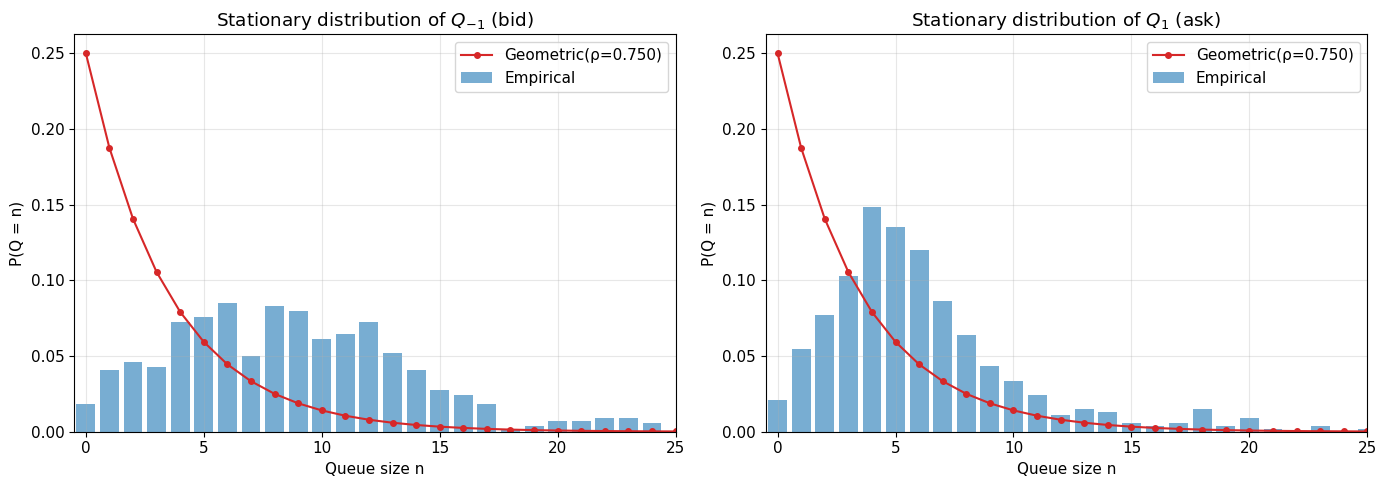

In [8]:
# ── Plot: empirical vs theoretical ────────────────────────────────
max_n = 25
ns = np.arange(0, max_n + 1)

# Theoretical: geometric distribution P(Q=n) = (1-ρ) * ρ^n
pi_theo = (1 - rho) * rho ** ns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, samples, label in [
    (axes[0], q_bid_samples, '$Q_{-1}$ (bid)'),
    (axes[1], q_ask_samples, '$Q_{ 1}$ (ask)'),
]:
    # Empirical histogram
    counts_emp, _ = np.histogram(samples, bins=np.arange(-0.5, max_n + 1.5, 1), density=True)
    ax.bar(ns, counts_emp[:max_n+1], alpha=0.6, width=0.8, label='Empirical', color='C0')
    
    # Theoretical
    ax.plot(ns, pi_theo, 'o-', color='C3', markersize=4, lw=1.5, label=f'Geometric(ρ={rho:.3f})')
    
    ax.set_xlabel('Queue size n')
    ax.set_ylabel('P(Q = n)')
    ax.set_title(f'Stationary distribution of {label}')
    ax.legend()
    ax.set_xlim(-0.5, max_n)

plt.tight_layout()
plt.show()

## 5. Next-Event Probabilities (Formule fermée vs Simulation)

For a non-empty queue in the constant model:
$$P(\text{next event} = \text{ADD}) = \frac{\lambda^+}{\lambda^+ + \lambda^- + \lambda^T}$$

In [9]:
# ── Theoretical probabilities ─────────────────────────────────────
total_rate = lp + lm + lt
p_add_theo = lp / total_rate
p_cancel_theo = lm / total_rate
p_trade_theo = lt / total_rate

print('=== Theoretical (formule fermée) ===')
print(f'P(ADD)    = {p_add_theo:.4f}')
print(f'P(CANCEL) = {p_cancel_theo:.4f}')
print(f'P(TRADE)  = {p_trade_theo:.4f}')

# ── Empirical from simulation ─────────────────────────────────────
# Count events on Q_1 when Q_1 > 0
events_q1 = [e for e in result.events if e.queue_index == 1]
n_add = sum(1 for e in events_q1 if e.event_type == EventType.ADD)
n_cancel = sum(1 for e in events_q1 if e.event_type == EventType.CANCEL)
n_trade = sum(1 for e in events_q1 if e.event_type == EventType.TRADE)
n_total = n_add + n_cancel + n_trade

print(f'\n=== Empirical (from {n_total} events on Q_1) ===')
if n_total > 0:
    print(f'P(ADD)    = {n_add/n_total:.4f}')
    print(f'P(CANCEL) = {n_cancel/n_total:.4f}')
    print(f'P(TRADE)  = {n_trade/n_total:.4f}')

=== Theoretical (formule fermée) ===
P(ADD)    = 0.4286
P(CANCEL) = 0.3571
P(TRADE)  = 0.2143

=== Empirical (from 808 events on Q_1) ===
P(ADD)    = 0.4319
P(CANCEL) = 0.3527
P(TRADE)  = 0.2153


## 6. Monte Carlo: Confidence Intervals

Run N independent simulations to estimate:
- Mean stationary queue size with 95% CI
- Price volatility (std of returns)

In [10]:
N_runs = 50
T_mc = 600.0
snap_dt = 1.0  # snapshot every second

sim_mc = Simulator(model, seed=0)
results_mc = sim_mc.run_batch(
    initial_state=model.create_initial_state(q_bid=5, q_ask=5),
    T=T_mc, n_runs=N_runs,
    snapshot_interval=snap_dt,
    record_full_path=True,
)
print(f'Completed {N_runs} runs')

Completed 50 runs


In [11]:
# ── Stationary queue sizes across runs ────────────────────────────
mean_q_bid = []
mean_q_ask = []
final_prices = []
n_price_changes_list = []

for r in results_mc:
    # Use second half of snapshots (burn-in removed)
    snaps = r.snapshots[len(r.snapshots)//2:]
    mean_q_bid.append(np.mean([s.q(-1) for _, s in snaps]))
    mean_q_ask.append(np.mean([s.q(1) for _, s in snaps]))
    _, p = r.price_array()
    final_prices.append(p[-1])
    n_price_changes_list.append(r.n_price_changes)

mean_q_bid = np.array(mean_q_bid)
mean_q_ask = np.array(mean_q_ask)

print('=== Stationary queue size (Monte Carlo) ===')
print(f'E[Q_bid] = {mean_q_bid.mean():.2f} ± {1.96*mean_q_bid.std()/np.sqrt(N_runs):.2f} (95% CI)')
print(f'E[Q_ask] = {mean_q_ask.mean():.2f} ± {1.96*mean_q_ask.std()/np.sqrt(N_runs):.2f} (95% CI)')
print(f'Theoretical: {rho/(1-rho):.2f}')
print()
print('=== Price changes ===')
npc = np.array(n_price_changes_list)
print(f'Mean price changes per run: {npc.mean():.1f} ± {1.96*npc.std()/np.sqrt(N_runs):.1f}')

=== Stationary queue size (Monte Carlo) ===
E[Q_bid] = 8.25 ± 0.60 (95% CI)
E[Q_ask] = 8.32 ± 0.62 (95% CI)
Theoretical: 3.00

=== Price changes ===
Mean price changes per run: 98.5 ± 5.5


In [12]:
# ── Volatility analysis ───────────────────────────────────────────
volatilities = []
for r in results_mc:
    t_p, p_p = r.price_array()
    if len(p_p) > 10:
        # Compute 10-second returns std
        dt_sample = 10.0
        sample_times = np.arange(0, T_mc, dt_sample)
        sample_prices = np.interp(sample_times, t_p, p_p)
        returns = np.diff(sample_prices) / sample_prices[:-1]
        volatilities.append(returns.std() * 1e4)  # in bps

vol = np.array(volatilities)
print(f'10-second volatility: {vol.mean():.2f} ± {1.96*vol.std()/np.sqrt(len(vol)):.2f} bps')

10-second volatility: 0.53 ± 0.02 bps


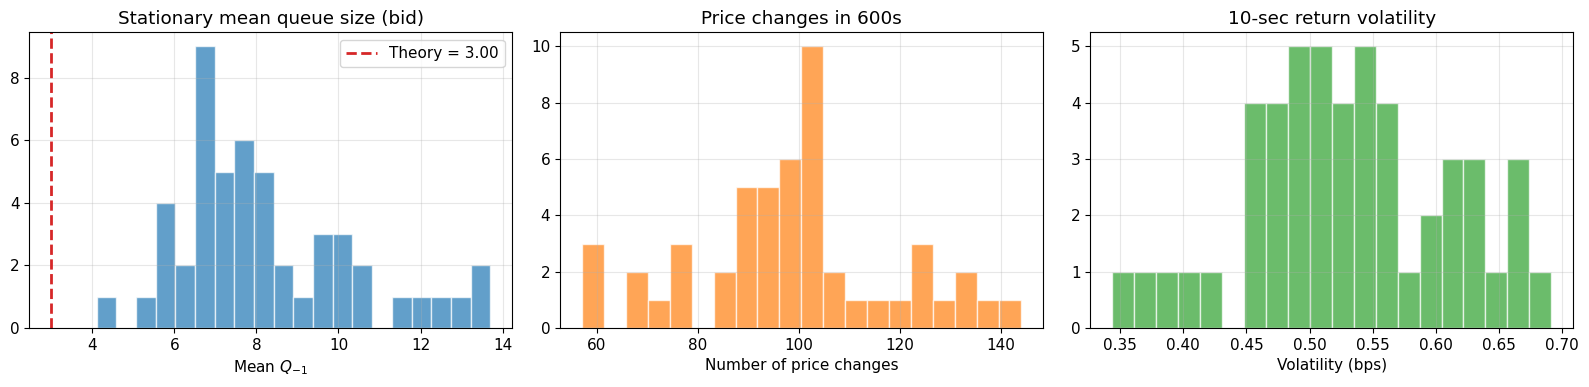

In [13]:
# ── Visualization: MC distributions ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(mean_q_bid, bins=20, alpha=0.7, color='C0', edgecolor='white')
axes[0].axvline(rho/(1-rho), color='C3', ls='--', lw=2, label=f'Theory = {rho/(1-rho):.2f}')
axes[0].set_xlabel('Mean $Q_{-1}$')
axes[0].set_title('Stationary mean queue size (bid)')
axes[0].legend()

axes[1].hist(n_price_changes_list, bins=20, alpha=0.7, color='C1', edgecolor='white')
axes[1].set_xlabel('Number of price changes')
axes[1].set_title(f'Price changes in {T_mc:.0f}s')

axes[2].hist(vol, bins=20, alpha=0.7, color='C2', edgecolor='white')
axes[2].set_xlabel('Volatility (bps)')
axes[2].set_title('10-sec return volatility')

plt.tight_layout()
plt.show()

## 7. Parameter Sensitivity

How does the drift $d = \lambda^+ - \lambda^- - \lambda^T$ affect the dynamics?

In [14]:
# ── Sweep λ+ from 0.3 to 0.75 (keeping λ-=0.5, λT=0.3) ─────────
lp_values = np.arange(0.3, 0.76, 0.05)
mean_queues = []
mean_price_changes = []

for lp_val in lp_values:
    p = {
        'lambda_plus':  {-1: lp_val, 1: lp_val},
        'lambda_minus': {-1: 0.5, 1: 0.5},
        'lambda_trade': {-1: 0.3, 1: 0.3},
        'lambda_bid': 1.5, 'lambda_ask': 1.5,
        'new_queue_mean': 5.0,
    }
    m = QRConstant(I=1, params=p)
    s = Simulator(m, seed=0)
    rs = s.run_batch(m.create_initial_state(q_bid=5, q_ask=5),
                     T=300, n_runs=20, snapshot_interval=1.0, record_full_path=True)
    
    mq = [np.mean([st.q(-1) for _, st in r.snapshots[len(r.snapshots)//2:]])
          for r in rs]
    mpc = [r.n_price_changes for r in rs]
    mean_queues.append((np.mean(mq), np.std(mq)))
    mean_price_changes.append((np.mean(mpc), np.std(mpc)))
    
    drift = lp_val - 0.5 - 0.3
    rho_val = lp_val / 0.8
    print(f'λ+={lp_val:.2f}, drift={drift:+.2f}, ρ={rho_val:.3f}, '
          f'E[Q]={np.mean(mq):.1f}, price_changes={np.mean(mpc):.0f}')

λ+=0.30, drift=-0.50, ρ=0.375, E[Q]=5.6, price_changes=100
λ+=0.35, drift=-0.45, ρ=0.437, E[Q]=6.4, price_changes=87
λ+=0.40, drift=-0.40, ρ=0.500, E[Q]=6.1, price_changes=85
λ+=0.45, drift=-0.35, ρ=0.562, E[Q]=6.9, price_changes=74
λ+=0.50, drift=-0.30, ρ=0.625, E[Q]=6.6, price_changes=68
λ+=0.55, drift=-0.25, ρ=0.687, E[Q]=7.1, price_changes=59
λ+=0.60, drift=-0.20, ρ=0.750, E[Q]=8.1, price_changes=50
λ+=0.65, drift=-0.15, ρ=0.812, E[Q]=8.4, price_changes=43
λ+=0.70, drift=-0.10, ρ=0.875, E[Q]=9.1, price_changes=32
λ+=0.75, drift=-0.05, ρ=0.937, E[Q]=11.1, price_changes=28


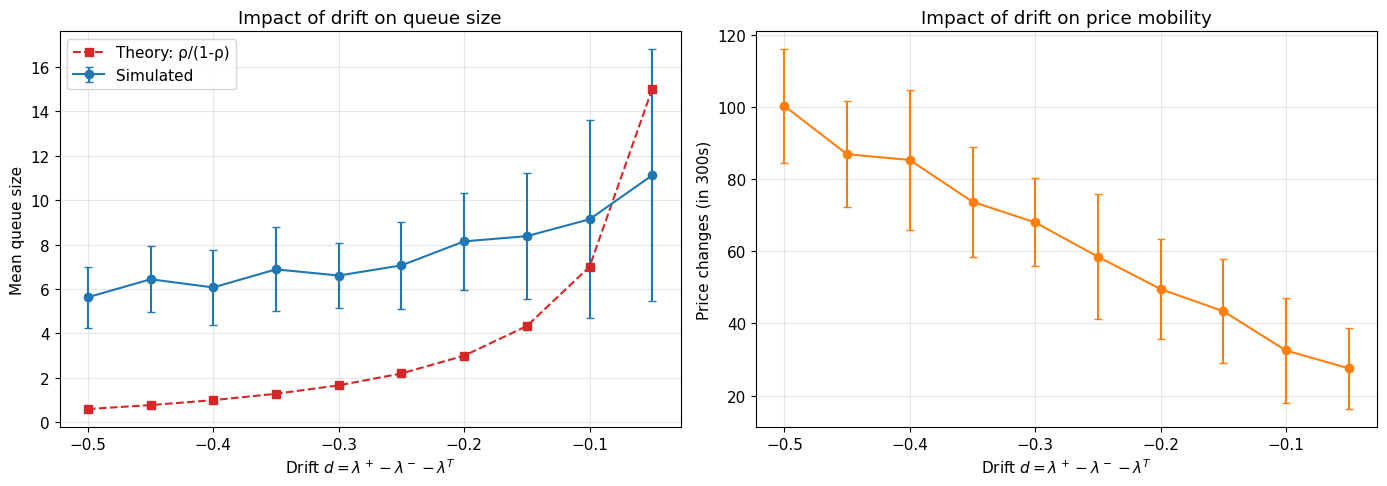

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

drifts = lp_values - 0.5 - 0.3
mq_mean = [x[0] for x in mean_queues]
mq_std = [x[1] for x in mean_queues]
mpc_mean = [x[0] for x in mean_price_changes]
mpc_std = [x[1] for x in mean_price_changes]

# Theoretical mean queue: ρ/(1-ρ)
rho_vals = lp_values / 0.8
theo_mean = rho_vals / (1 - rho_vals)
theo_mean[rho_vals >= 1] = np.nan

axes[0].errorbar(drifts, mq_mean, yerr=mq_std, fmt='o-', capsize=3, color='C0', label='Simulated')
axes[0].plot(drifts, theo_mean, 's--', color='C3', label='Theory: ρ/(1-ρ)')
axes[0].set_xlabel('Drift $d = \\lambda^+ - \\lambda^- - \\lambda^T$')
axes[0].set_ylabel('Mean queue size')
axes[0].set_title('Impact of drift on queue size')
axes[0].legend()

axes[1].errorbar(drifts, mpc_mean, yerr=mpc_std, fmt='o-', capsize=3, color='C1')
axes[1].set_xlabel('Drift $d = \\lambda^+ - \\lambda^- - \\lambda^T$')
axes[1].set_ylabel('Price changes (in 300s)')
axes[1].set_title('Impact of drift on price mobility')

plt.tight_layout()
plt.show()

## 8. Rare Events: Total Consumption of First Limit

What is the distribution of the queue size on the **opposite** first limit  
at the moment when a first limit is completely depleted?

In [16]:
# ── Long simulation to collect rare events ────────────────────────
long_sim = Simulator(model, seed=123)
long_result = long_sim.run(
    model.create_initial_state(q_bid=5, q_ask=5),
    T=10000.0,  # long run
    record_full_path=True,
)
print(f'Events: {long_result.n_events}, Price changes: {long_result.n_price_changes}')

# ── Find moments when first limit empties ──────────────────────────
# A first limit empties when: TRADE or CANCEL on Q_{±1} brings it to 0
depletion_events = []
for idx, e in enumerate(long_result.events):
    if (e.event_type in (EventType.TRADE, EventType.CANCEL)
        and abs(e.queue_index) == 1
        and e.size == -1):
        # Check if this brought the queue to 0
        # We look at the queue state AFTER this event
        # from queue_path (which records state after each event)
        t_idx = idx + 1  # queue_path[0] is initial, queue_path[idx+1] is after event idx
        if t_idx < len(long_result.queue_path):
            _, q_after = long_result.queue_path[t_idx]
            qi = e.queue_index
            if q_after.get(qi, 0) == 0:
                # First limit just emptied!
                opposite = -qi
                q_opposite = q_after.get(opposite, 0)
                depletion_events.append({
                    'time': e.time,
                    'depleted_queue': qi,
                    'event_type': e.event_type.name,
                    'opposite_queue_size': q_opposite,
                })

print(f'\nFirst-limit depletion events: {len(depletion_events)}')

Events: 29062, Price changes: 1625

First-limit depletion events: 832


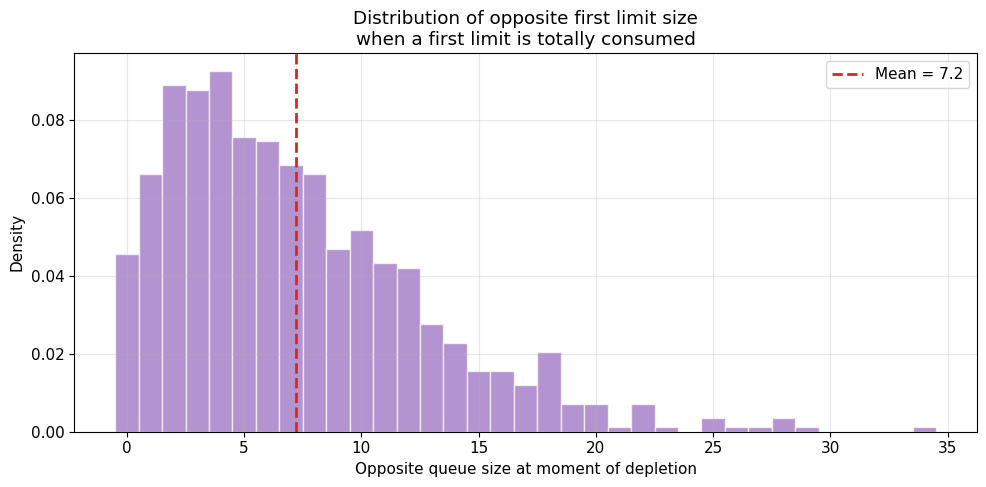

In [17]:
if depletion_events:
    opp_sizes = [d['opposite_queue_size'] for d in depletion_events]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(opp_sizes, bins=np.arange(-0.5, max(opp_sizes)+1.5, 1),
            density=True, alpha=0.7, color='C4', edgecolor='white')
    ax.axvline(np.mean(opp_sizes), color='C3', ls='--', lw=2,
               label=f'Mean = {np.mean(opp_sizes):.1f}')
    ax.set_xlabel('Opposite queue size at moment of depletion')
    ax.set_ylabel('Density')
    ax.set_title('Distribution of opposite first limit size\nwhen a first limit is totally consumed')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No depletion events found — try longer simulation or more negative drift.')

Questions à poser :
- Que renvoie la fonction f(Q,i) ? qui est l_i ? Comment on interprète la quantité f(Q,i) ? C'est vraiment une table de correspondance ?
- Est-ce qu'on a bien, pour chaque queue, trois processus de poisson de paramètres \lambda_+, \lambda_- et \lambda_T ?